<a href="https://colab.research.google.com/github/atikhasan007/Generative-AI/blob/main/build%20an%20LLM-powered%20SQL%20agent%20using%20LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install langchain_community langchain_groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.12
    Uninstalling langchain-core-1.2.12:
      Successfully uninstalled langchain-core-1.2.12
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
goo

In [2]:
groq_api_key=""

In [4]:
from langchain_groq import ChatGroq

In [5]:
llm = ChatGroq(model="llama-3.1-8b-instant",
               groq_api_key=groq_api_key)

2. Establishing database connection

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipin20/transaction-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'transaction-data' dataset.
Path to dataset files: /kaggle/input/transaction-data


In [10]:
from langchain_community.utilities import SQLDatabase
from sqlalchemy import create_engine
import pandas as pd

df = pd.read_csv("/kaggle/input/transaction-data/transaction_data.csv")
engine = create_engine("sqlite:///data.db")
df.to_sql("data", engine, index=False, if_exists='replace')
db = SQLDatabase(engine=engine)

In [11]:
db

3. Defining graph State

In [12]:
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from typing import Literal

class State(TypedDict):
    sql_question: str
    sql_query: str
    sql_query_execution_status: Literal["success", "failure"]
    sql_error_count: int
    sql_query_error: str
    sql_result: str
    sql_answer: str

4. Creating nodes and edges

The agent is separated into task-specific nodes, and the nodes required for the graph are defined in the following section.

* write_query — generate SQL from natural language question
* execute_query — execute SQL query
* cannot_answer — fallback after multiple failures
* sql_router — routing logic based on result/error status
* generate_answer — format result from database into output for user


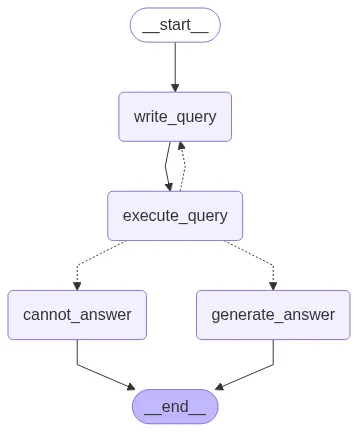

4.1. write_query

In [13]:
from typing_extensions import Annotated

class QueryOutput(TypedDict):
    """Generated SQL query."""
    generated_sql_query: Annotated[str, ..., "Syntactically valid SQL query."]

In [14]:
print(db.get_table_info())


CREATE TABLE data (
	"UserId" BIGINT, 
	"TransactionId" BIGINT, 
	"TransactionTime" TEXT, 
	"ItemCode" BIGINT, 
	"ItemDescription" TEXT, 
	"NumberOfItemsPurchased" BIGINT, 
	"CostPerItem" FLOAT, 
	"Country" TEXT
)

/*
3 rows from data table:
UserId	TransactionId	TransactionTime	ItemCode	ItemDescription	NumberOfItemsPurchased	CostPerItem	Country
278166	6355745	Sat Feb 02 12:50:00 IST 2019	465549	FAMILY ALBUM WHITE PICTURE FRAME	6	11.73	United Kingdom
337701	6283376	Wed Dec 26 09:06:00 IST 2018	482370	LONDON BUS COFFEE MUG	3	3.52	United Kingdom
267099	6385599	Fri Feb 15 09:45:00 IST 2019	490728	SET 12 COLOUR PENCILS DOLLY GIRL 	72	0.9	France
*/


In [15]:
df.head()

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


In [16]:
from langchain_core.prompts import ChatPromptTemplate

system_message = """
Given an input question, create a syntactically correct {dialect} query to run to help find the answer.

Never query for all the columns from a specific table, only ask for a few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Only use the following tables:
{table_info}

Schema highlights:
- TransactionYear: the 4-digit year (e.g., 2024)
- TransactionMonth: an integer from 1 to 12 representing the month
- TransactionDay: an integer from 1 to 31 representing the day of the month
    Example: To get all transactions that occurred on January 16, 2024, use: WHERE TransactionYear = 2024 AND TransactionMonth = 1 AND TransactionDay = 16
- Category (e.g. 'Healthcare', 'Electronics', 'Unknown')
- Merchant (e.g. 'MediCare', 'ElectroWorld', 'Unknown')
- Channel (one of 'Online', 'ATM', 'Branch')
- CustomerAge (INT, in years)
- CustomerOccupation (one of 'Retired', 'Engineer', 'Student', 'Teacher', 'Doctor')
- CreditScore (INT, 300-850)
- RiskProfile (one of 'Low', 'Medium', 'High')
- CustomerTenure (INT, years with bank)
- PreferredSpendingCategory (e.g. 'Electronics', 'Entertainment', ...)
- MostInterestedProduct (e.g. 'Home Loan', 'Credit Card', ...)
- IncomeBracket (string ranges: '<25K', '25K-50K','50K-100K', '150K-200K', '200K-250K', '300K-350K')
 - For comparisons (">200K"), include all brackets whose lower bound exceeds the threshold (e.g., IN ('200K-250K', '300K-350K')).
"""

user_prompt = """
Question: {input}
Use the following error information if there is any: {query_error}
"""

query_prompt_template = ChatPromptTemplate(
    [("system", system_message), ("user", user_prompt)]
)

In [18]:
def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "table_info": db.get_table_info(),
            "input": state["sql_question"],
            "query_error": state.get("sql_query_error", ""),
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    state["sql_query"] = result["generated_sql_query"]

    return state

write_query in action:

In [35]:
write_query({"sql_question": "“What is the distinct country name associated with user ID 278166?”"})




{'sql_question': '“What is the distinct country name associated with user ID 278166?”',
 'sql_query': 'SELECT DISTINCT Country FROM data WHERE UserId = 278166'}

4.2. execute_query

In [33]:
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool

def execute_query(state: State):
    """Execute SQL query and set query_execution_status."""
    execute_query_tool = QuerySQLDatabaseTool(db=db)
    result = execute_query_tool.invoke(state["sql_query"])

    if isinstance(result, str) and result.startswith("Error:"):
        state["sql_query_execution_status"] = "failure"
        state["sql_query_error"] = result
        error_count = state.get("sql_error_count", 0)
        state["sql_error_count"] = error_count + 1

    else:
        state["sql_result"] = result
        state["sql_query_execution_status"] = "success"
        state["sql_query_error"] = ""
        state["sql_error_count"] = 0   # resetting to 0 for future use of attribute

    return state

In [36]:
execute_query({'sql_query': 'SELECT DISTINCT Country FROM data WHERE UserId = 278166'})



{'sql_query': 'SELECT DISTINCT Country FROM data WHERE UserId = 278166',
 'sql_result': "[('United Kingdom',)]",
 'sql_query_execution_status': 'success',
 'sql_query_error': '',
 'sql_error_count': 0}

4.3. cannot_answer

In [37]:
def cannot_answer(state: State):
  """Cannot answer question; return a default answer."""

  state["sql_error_count"] = 0      # resetting to 0 for future use of attribute
  state["sql_answer"] = "I'm sorry, but I cannot find the information you're looking for."

  return state

4.4 sql_router

In [38]:
def sql_router(state: State):
  """Routes to generate_answer, cannot_answer or write_query based on query_execution_status."""

  if state["sql_query_execution_status"] == "success":
    return "generate_answer"

  elif state["sql_query_execution_status"] == "failure":
    if state["sql_error_count"] < 2:
      return "write_query"

    else:
      return "cannot_answer"

4.5 generate_answer

In [39]:
def generate_answer(state: State):

    prompt = (
        "You are a banking assistant responding to a manager's queries about customer transactions.\n"
        "Given the manager's question and the result of the internal SQL query used to retrieve the relevant data, answer the question clearly and professionally.\n"
        "Use a well-formatted table with clear headers **only if** the question requires structured data, such as a list of transactions, balances over time, or multiple entries.\n"
        "Otherwise, respond in plain text that reads naturally.\n"
        "Do not mention SQL queries, databases, or how the data was retrieved.\n"
        "Avoid phrases like 'Hello there!', 'I'm happy to help...', or anything overly formal or robotic.\n"
        "Give a direct, informative, human-like answer as if responding to a manager's internal query.\n\n"
        f"Manager's Question: {state['sql_question']}\n"
        f"Result: {state['sql_result']}"
    )

    response = llm.invoke(prompt)
    state["sql_answer"] = response.content

    return state

In [59]:
generate_answer({'sql_question': "How many transactions are there for UserID '278166'?", 'sql_query': "SELECT COUNT(TransactionID) FROM data WHERE UserID = 'U001'", 'sql_result': '[(20,)]'})


{'sql_question': "How many transactions are there for UserID '278166'?",
 'sql_query': "SELECT COUNT(TransactionID) FROM data WHERE UserID = 'U001'",
 'sql_result': '[(20,)]',
 'sql_answer': "There is 1 transaction for UserID '278166'."}

5. Compiling and running the graph

In [60]:
from langgraph.graph import StateGraph, END

sql_graph_builder = StateGraph(State)

sql_graph_builder.set_entry_point("write_query")
sql_graph_builder.add_node("write_query", write_query)
sql_graph_builder.add_node("execute_query", execute_query)
sql_graph_builder.add_node("generate_answer", generate_answer)
sql_graph_builder.add_node("cannot_answer", cannot_answer)

sql_graph_builder.add_edge("write_query", "execute_query")
sql_graph_builder.add_conditional_edges(
    "execute_query",
    sql_router,
    {
        "generate_answer": "generate_answer",
        "write_query": "write_query",
        "cannot_answer": "cannot_answer"
    }

)

sql_graph_builder.add_edge("generate_answer", END)
sql_graph_builder.add_edge("cannot_answer", END)

sql_graph_manager = sql_graph_builder.compile()


Graph in action

In [57]:
sql_graph_manager.invoke({
    "sql_question": "how many userid?"
})


{'sql_question': 'how many userid?',
 'sql_query': 'SELECT COUNT(UserId) FROM data',
 'sql_query_execution_status': 'success',
 'sql_error_count': 0,
 'sql_query_error': '',
 'sql_result': '[(1083818,)]',
 'sql_answer': 'There is 1 user ID.'}

In [61]:
sql_graph_manager.invoke({
    "sql_question": "how many userid?"
})


{'sql_question': 'how many userid?',
 'sql_query': 'SELECT COUNT(UserId) FROM data',
 'sql_query_execution_status': 'success',
 'sql_error_count': 0,
 'sql_query_error': '',
 'sql_result': '[(1083818,)]',
 'sql_answer': 'There is 1 unique user ID.'}

https://levelup.gitconnected.com/how-to-build-an-llm-powered-sql-agent-using-langgraph-367b3edd350a